# **External validation on MAESTRO with the Jensen–Shannon-based metrics**

## Settings & Imports

In [1]:
! git clone https://github.com/elisavetaslav/ITG-JS-persistent-homology.git
%cd ./ITG-JS-persistent-homology
!pip install -r requirements.txt

Cloning into 'ITG-JS-persistent-homology'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (244/244), done.
remote: Total 274 (delta 45), reused 255 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (274/274), 19.20 MiB | 17.43 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/ITG-JS-persistent-homology
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 57.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import mirdata
from mirdata.datasets import maestro
import os

ROOT = Path.cwd()
sys.path.append(str(ROOT))

from visualization.plotting import setup_notebook_plots
setup_notebook_plots()

In [3]:
from parts.maestro_extraction import add_parts_column_from_midi_path
from parts.duration_normalization import normalize_durations, compute_global_unit
from experiments.recompute import recompute_features_pure_js
from experiments.replication import run_small_dataset_pipeline

## Dataset Preprocessing

In [4]:
data_home = 'maestro_dataset/'
maestro_data = maestro.Dataset(data_home=data_home, version='2.0.0')

maestro_data.download(partial_download=['midi', 'metadata'])

56.5MB [00:02, 20.6MB/s]                            
504kB [00:00, 1.73MB/s]                            


In [5]:
tracks = maestro_data.load_tracks()
print(f"Loaded: {len(tracks)} tracks")

Loaded: 1282 tracks


In [6]:
records = []
for track_id, track in tracks.items():
    records.append({
        'track_id': track_id,
        'filename': os.path.basename(track.midi_path) if track.midi_path else None,
        'composer': track.canonical_composer,
        'title': track.canonical_title,
        'date': track.year,
        'split': track.split,
        'midi_path': track.midi_path,
        'duration': track.duration,
        'genre': None,
        'opus': None,
        'key': None,
        'movement': None,
    })

df_maestro = pd.DataFrame(records)
df_maestro.head(10)

,track_id,filename,composer,title,date,split,midi_path,duration,genre,opus,key,movement
0,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_201...,Alban Berg,Sonata Op. 1,2018,train,maestro_dataset/2018/MIDI-Unprocessed_Chamber3...,698.661160,None,None,None,None
1,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MID--AU...,Alban Berg,Sonata Op. 1,2008,train,maestro_dataset/2008/MIDI-Unprocessed_03_R2_20...,759.518471,None,None,None,None
2,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,MIDI-Unprocessed_066_PIANO066_MID--AUDIO-split...,Alban Berg,Sonata Op. 1,2017,train,maestro_dataset/2017/MIDI-Unprocessed_066_PIAN...,464.649433,None,None,None,None
3,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MID--AU...,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",2004,train,maestro_dataset/2004/MIDI-Unprocessed_XP_21_R1...,872.640588,None,None,None,None
4,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AU...,Alexander Scriabin,"3 Etudes, Op. 65",2006,validation,maestro_dataset/2006/MIDI-Unprocessed_17_R1_20...,397.857508,None,None,None,None
5,2009/MIDI-Unprocessed_07_R1_2009_04-05_ORIG_MI...,MIDI-Unprocessed_07_R1_2009_04-05_ORIG_MID--AU...,Alexander Scriabin,"5 Preludes, Op.15",2009,validation,maestro_dataset/2009/MIDI-Unprocessed_07_R1_20...,400.557826,None,None,None,None
6,2009/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MI...,MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AU...,Alexander Scriabin,"Entragete, Op.63",2009,test,maestro_dataset/2009/MIDI-Unprocessed_11_R1_20...,163.745830,None,None,None,None
7,2013/ORIG-MIDI_03_7_8_13_Group__MID--AUDIO_19_...,ORIG-MIDI_03_7_8_13_Group__MID--AUDIO_19_R2_20...,Alexander Scriabin,"Etude Op. 2 No.1; Etudes Op. 8, Nos. 5, 11 an...",2013,train,maestro_dataset/2013/ORIG-MIDI_03_7_8_13_Group...,563.904351,None,None,None,None
8,2009/MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MI...,MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AU...,Alexander Scriabin,"Etude Op. 42, Nos. 4 & 5",2009,test,maestro_dataset/2009/MIDI-Unprocessed_02_R1_20...,136.315302,None,None,None,None
9,2009/MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MI...,MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AU...,Alexander Scriabin,"Etude Op. 8, No. 13",2009,validation,maestro_dataset/2009/MIDI-Unprocessed_02_R1_20...,167.085837,None,None,None,None


### Validation split only

In [7]:
df_m = add_parts_column_from_midi_path(df_maestro, split_n='validation')

sample = df_m['parts'].iloc[0]
print(len(sample))
print(sample[0].keys())
df_m.head()

Processed 137 / 137 files successfully.
1
dict_keys(['part_index', 'num_notes', 'pitches', 'durations', 'onsets'])


,track_id,filename,composer,title,date,split,midi_path,duration,genre,opus,key,movement,parts
4,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AU...,Alexander Scriabin,"3 Etudes, Op. 65",2006,validation,maestro_dataset/2006/MIDI-Unprocessed_17_R1_20...,397.857508,None,None,None,None,"[{'part_index': 0, 'num_notes': 4217, 'pitches..."
5,2009/MIDI-Unprocessed_07_R1_2009_04-05_ORIG_MI...,MIDI-Unprocessed_07_R1_2009_04-05_ORIG_MID--AU...,Alexander Scriabin,"5 Preludes, Op.15",2009,validation,maestro_dataset/2009/MIDI-Unprocessed_07_R1_20...,400.557826,None,None,None,None,"[{'part_index': 0, 'num_notes': 2699, 'pitches..."
9,2009/MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MI...,MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AU...,Alexander Scriabin,"Etude Op. 8, No. 13",2009,validation,maestro_dataset/2009/MIDI-Unprocessed_02_R1_20...,167.085837,None,None,None,None,"[{'part_index': 0, 'num_notes': 2967, 'pitches..."
15,2009/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MI...,MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AU...,Alexander Scriabin,"Fragilite, Op.51",2009,validation,maestro_dataset/2009/MIDI-Unprocessed_11_R1_20...,138.421336,None,None,None,None,"[{'part_index': 0, 'num_notes': 1120, 'pitches..."
24,2013/ORIG-MIDI_01_7_6_13_Group__MID--AUDIO_03_...,ORIG-MIDI_01_7_6_13_Group__MID--AUDIO_03_R1_20...,Alexander Scriabin,"Sonata No. 4 in F-sharp Major ,Op.30",2013,validation,maestro_dataset/2013/ORIG-MIDI_01_7_6_13_Group...,440.110404,None,None,None,None,"[{'part_index': 0, 'num_notes': 5937, 'pitches..."


In [8]:
df_m['composer'].value_counts()

,count
composer,
Frédéric Chopin,31
Franz Liszt,18
Sergei Rachmaninoff,18
Johann Sebastian Bach,14
Ludwig van Beethoven,12
Robert Schumann,8
Alexander Scriabin,7
Johannes Brahms,5
Franz Schubert,4


In [9]:
js_scale=1.0
edge_eps=1e-6

df_work = df_m.copy()

GLOBAL_DF_MULT = compute_global_unit(df_work)
normalize_durations(df_work, GLOBAL_DF_MULT, apply_sqrt=False, inplace=True)

print(f"Recomputing features with pure JS: js_scale={js_scale}, edge_eps={edge_eps} ...")
df_valid = recompute_features_pure_js(df_work, js_scale=js_scale, edge_eps=edge_eps, min_num_parts=1)

Recomputing features with pure JS: js_scale=1.0, edge_eps=1e-06 ...
Successfully processed: 137 / 137


### Full-filtered dataset

In [10]:
df_m_full = add_parts_column_from_midi_path(df_maestro)
df_m_full['composer'].value_counts()

Processed 1282 / 1282 files successfully.


,count
composer,
Frédéric Chopin,201
Franz Schubert,186
Ludwig van Beethoven,148
Johann Sebastian Bach,145
Franz Liszt,131
...,...
Nikolai Rimsky-Korsakov / Sergei Rachmaninoff,1
Orlando Gibbons,1
Robert Schumann / Franz Liszt,1


In [11]:
counts = df_m_full['composer'].value_counts()
composers_less_8 = counts[counts < 20].index.tolist()

df_filtered = df_m_full[
    ~(df_m_full['composer'].isin(composers_less_8)) &
    ~(df_m_full['composer'].str.contains('/', na=False))
].copy()

df_filtered['composer'].value_counts()

,count
composer,
Frédéric Chopin,201
Franz Schubert,186
Ludwig van Beethoven,148
Johann Sebastian Bach,145
Franz Liszt,131
Sergei Rachmaninoff,59
Robert Schumann,49
Claude Debussy,45
Joseph Haydn,40


## MAESTRO: baseline vs pure JS (val split and full-filtered)

Successfully processed: 137 / 137

=== SMALL DATASET ANALYSIS ===
composer
Frédéric Chopin                    31
Franz Liszt                        18
Sergei Rachmaninoff                18
Johann Sebastian Bach              14
Ludwig van Beethoven               12
Robert Schumann                     8
Alexander Scriabin                  7
Johannes Brahms                     5
Franz Schubert                      4
Joseph Haydn                        4
Wolfgang Amadeus Mozart             4
Felix Mendelssohn                   3
César Franck                        3
Mily Balakirev                      3
Franz Liszt / Vladimir Horowitz     2
Franz Schubert / Franz Liszt        1
Name: count, dtype: int64
=== Baseline ===
Explained variance (PC1+PC2): 0.788
PC1: 0.543, PC2: 0.246
Silhouette (full space): -0.3413
Silhouette (PC1+PC2): -0.4306
Davies-Bouldin: 3.8925
Intraclass variance (RMS):
  Alexander Scriabin = 1.4910
  César Franck = 0.1589
  Felix Mendelssohn = 0.7512
  Franz Liszt = 1.2

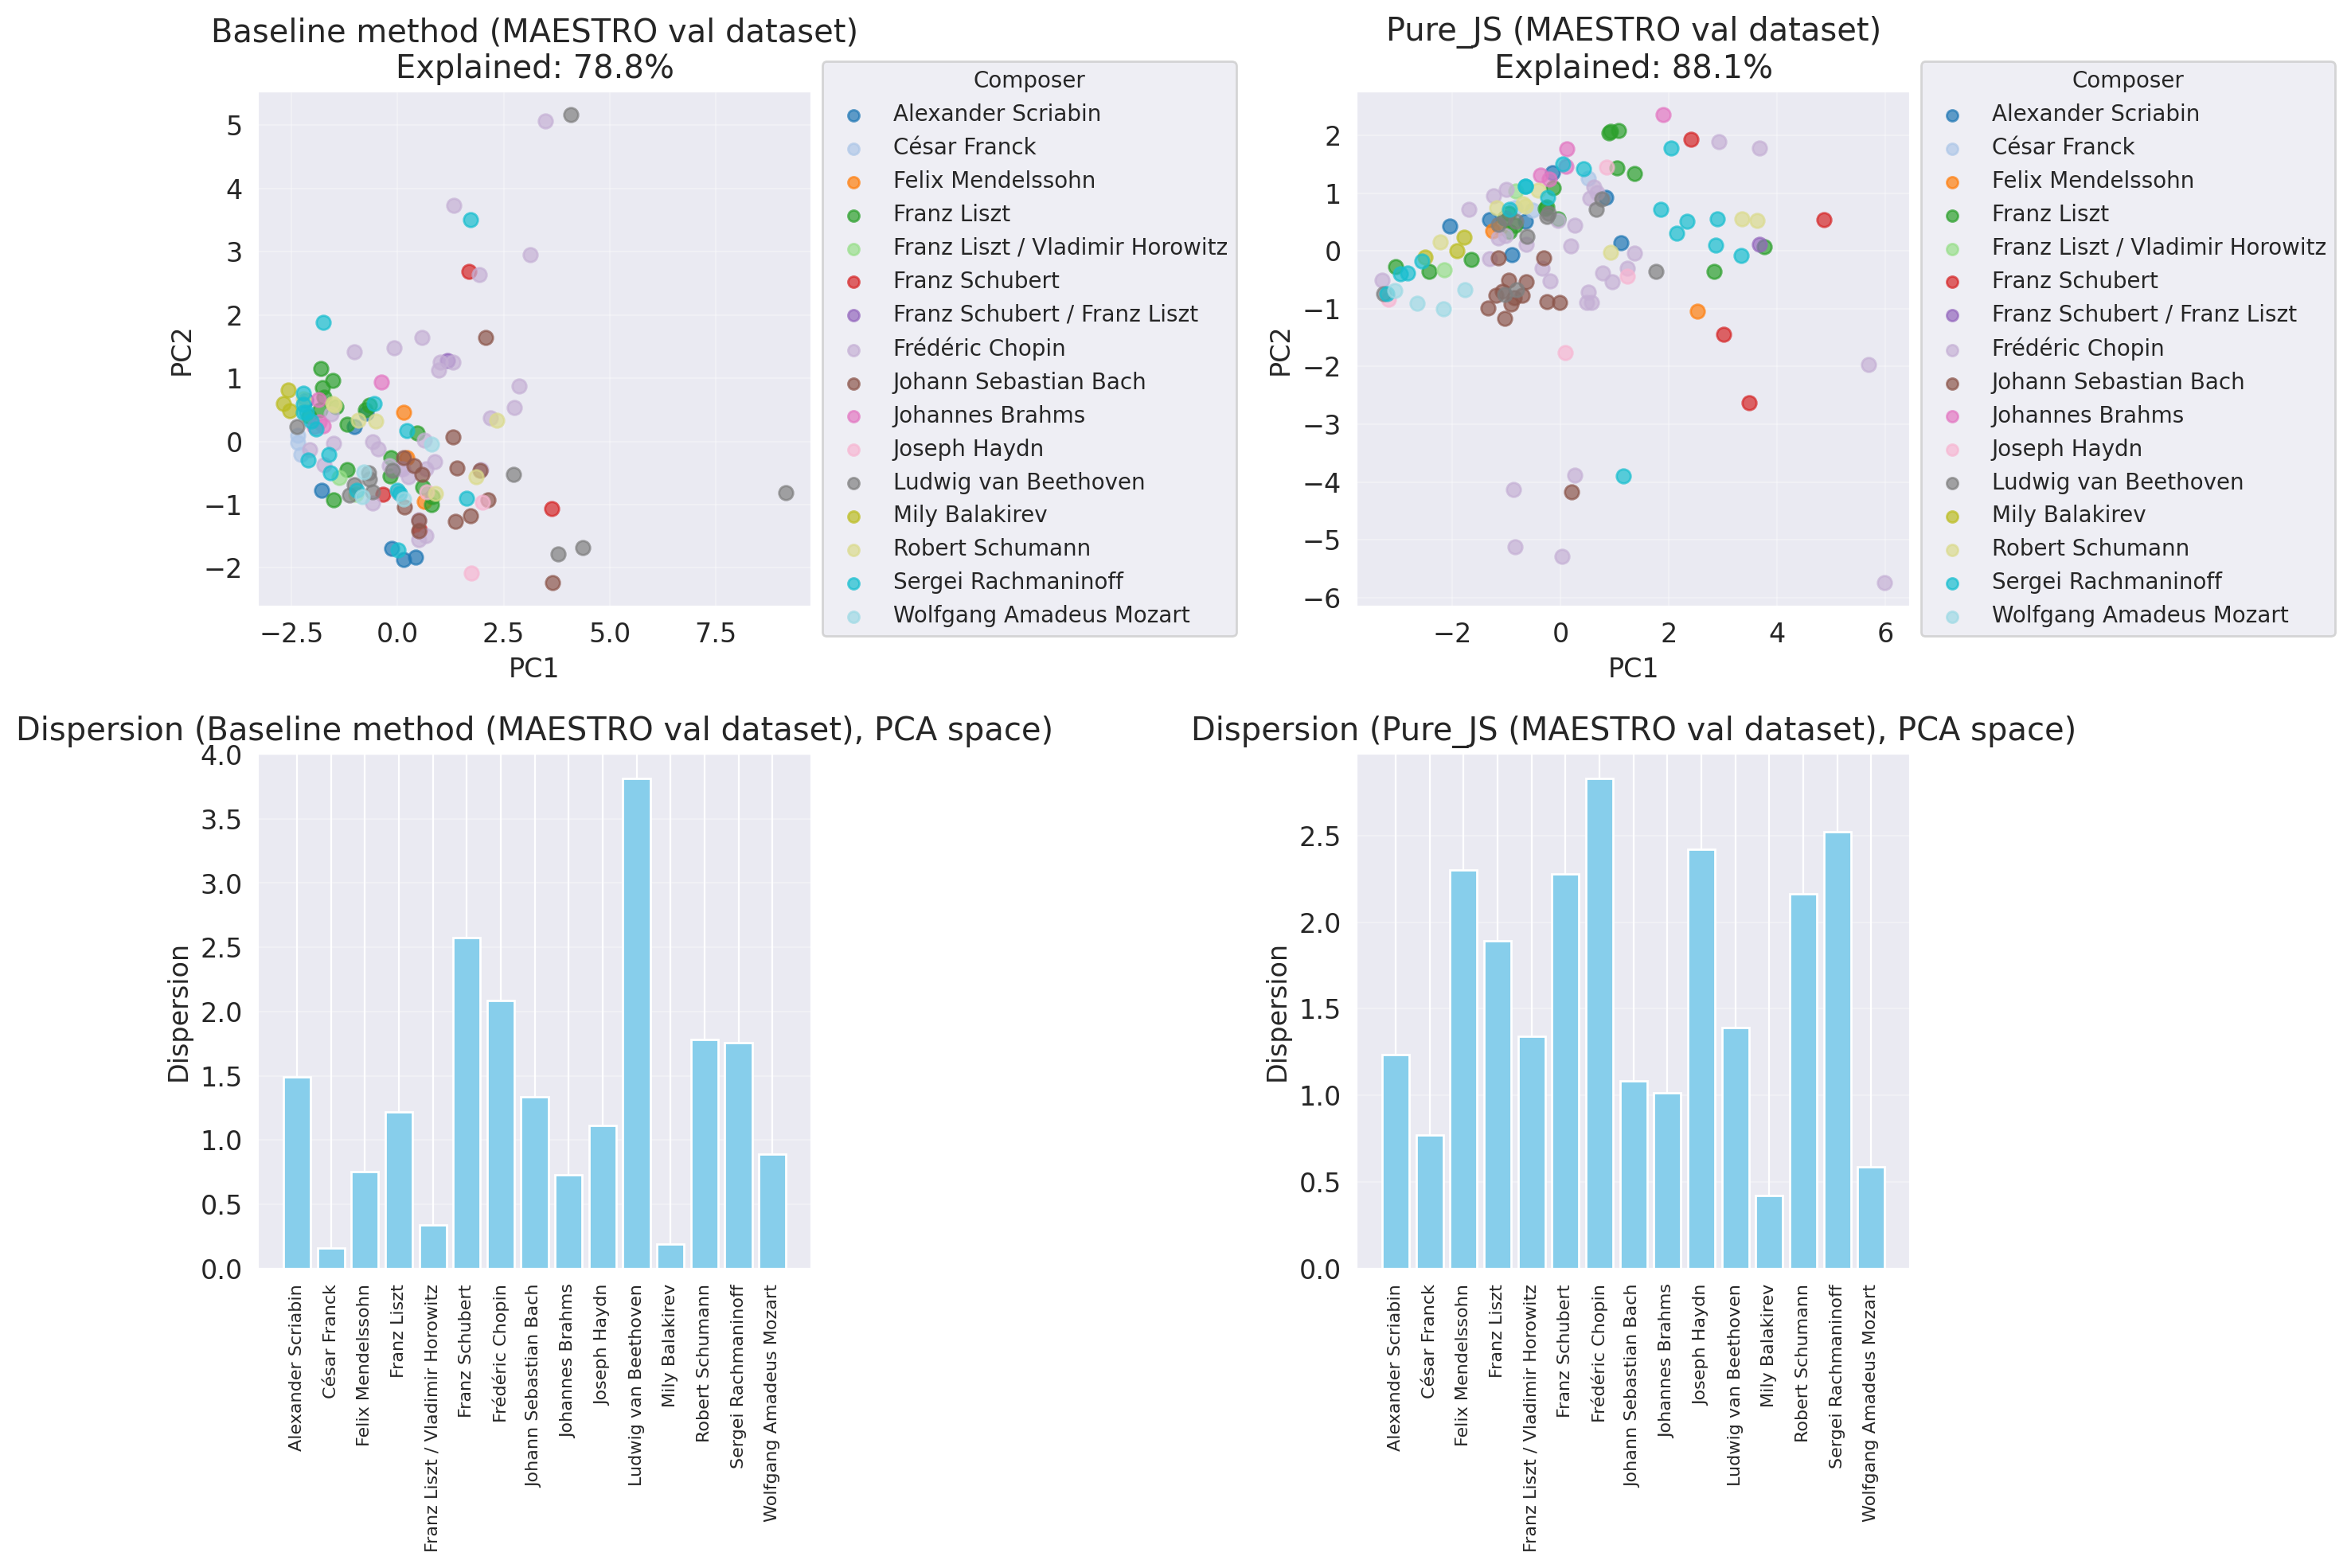

In [6]:
# Experiment on small validation split
small_results_js = run_small_dataset_pipeline(
    df_small=df_m,
    refresh_parts=False,
    apply_sqrt=False,
    use_pure_js=True,
    js_scale=1.0,
    edge_eps=1e-6,
    min_num_parts=1,
    composer_order=None,
    plot_title_suffix=" (MAESTRO val dataset)"
)

Successfully processed: 1163 / 1163

=== SMALL DATASET ANALYSIS ===
composer
Frédéric Chopin            201
Franz Schubert             186
Ludwig van Beethoven       148
Johann Sebastian Bach      145
Franz Liszt                131
Sergei Rachmaninoff         59
Robert Schumann             49
Claude Debussy              45
Joseph Haydn                40
Wolfgang Amadeus Mozart     38
Alexander Scriabin          35
Domenico Scarlatti          31
Felix Mendelssohn           29
Johannes Brahms             26
Name: count, dtype: int64
=== Baseline ===
Explained variance (PC1+PC2): 0.809
PC1: 0.556, PC2: 0.252
Silhouette (full space): -0.1773
Silhouette (PC1+PC2): -0.2194
Davies-Bouldin: 10.4395
Intraclass variance (RMS):
  Alexander Scriabin = 1.4899
  Claude Debussy = 2.6488
  Domenico Scarlatti = 1.9251
  Felix Mendelssohn = 1.4933
  Franz Liszt = 1.3477
  Franz Schubert = 1.7596
  Frédéric Chopin = 1.6908
  Johann Sebastian Bach = 2.4619
  Johannes Brahms = 1.3936
  Joseph Haydn = 2.573

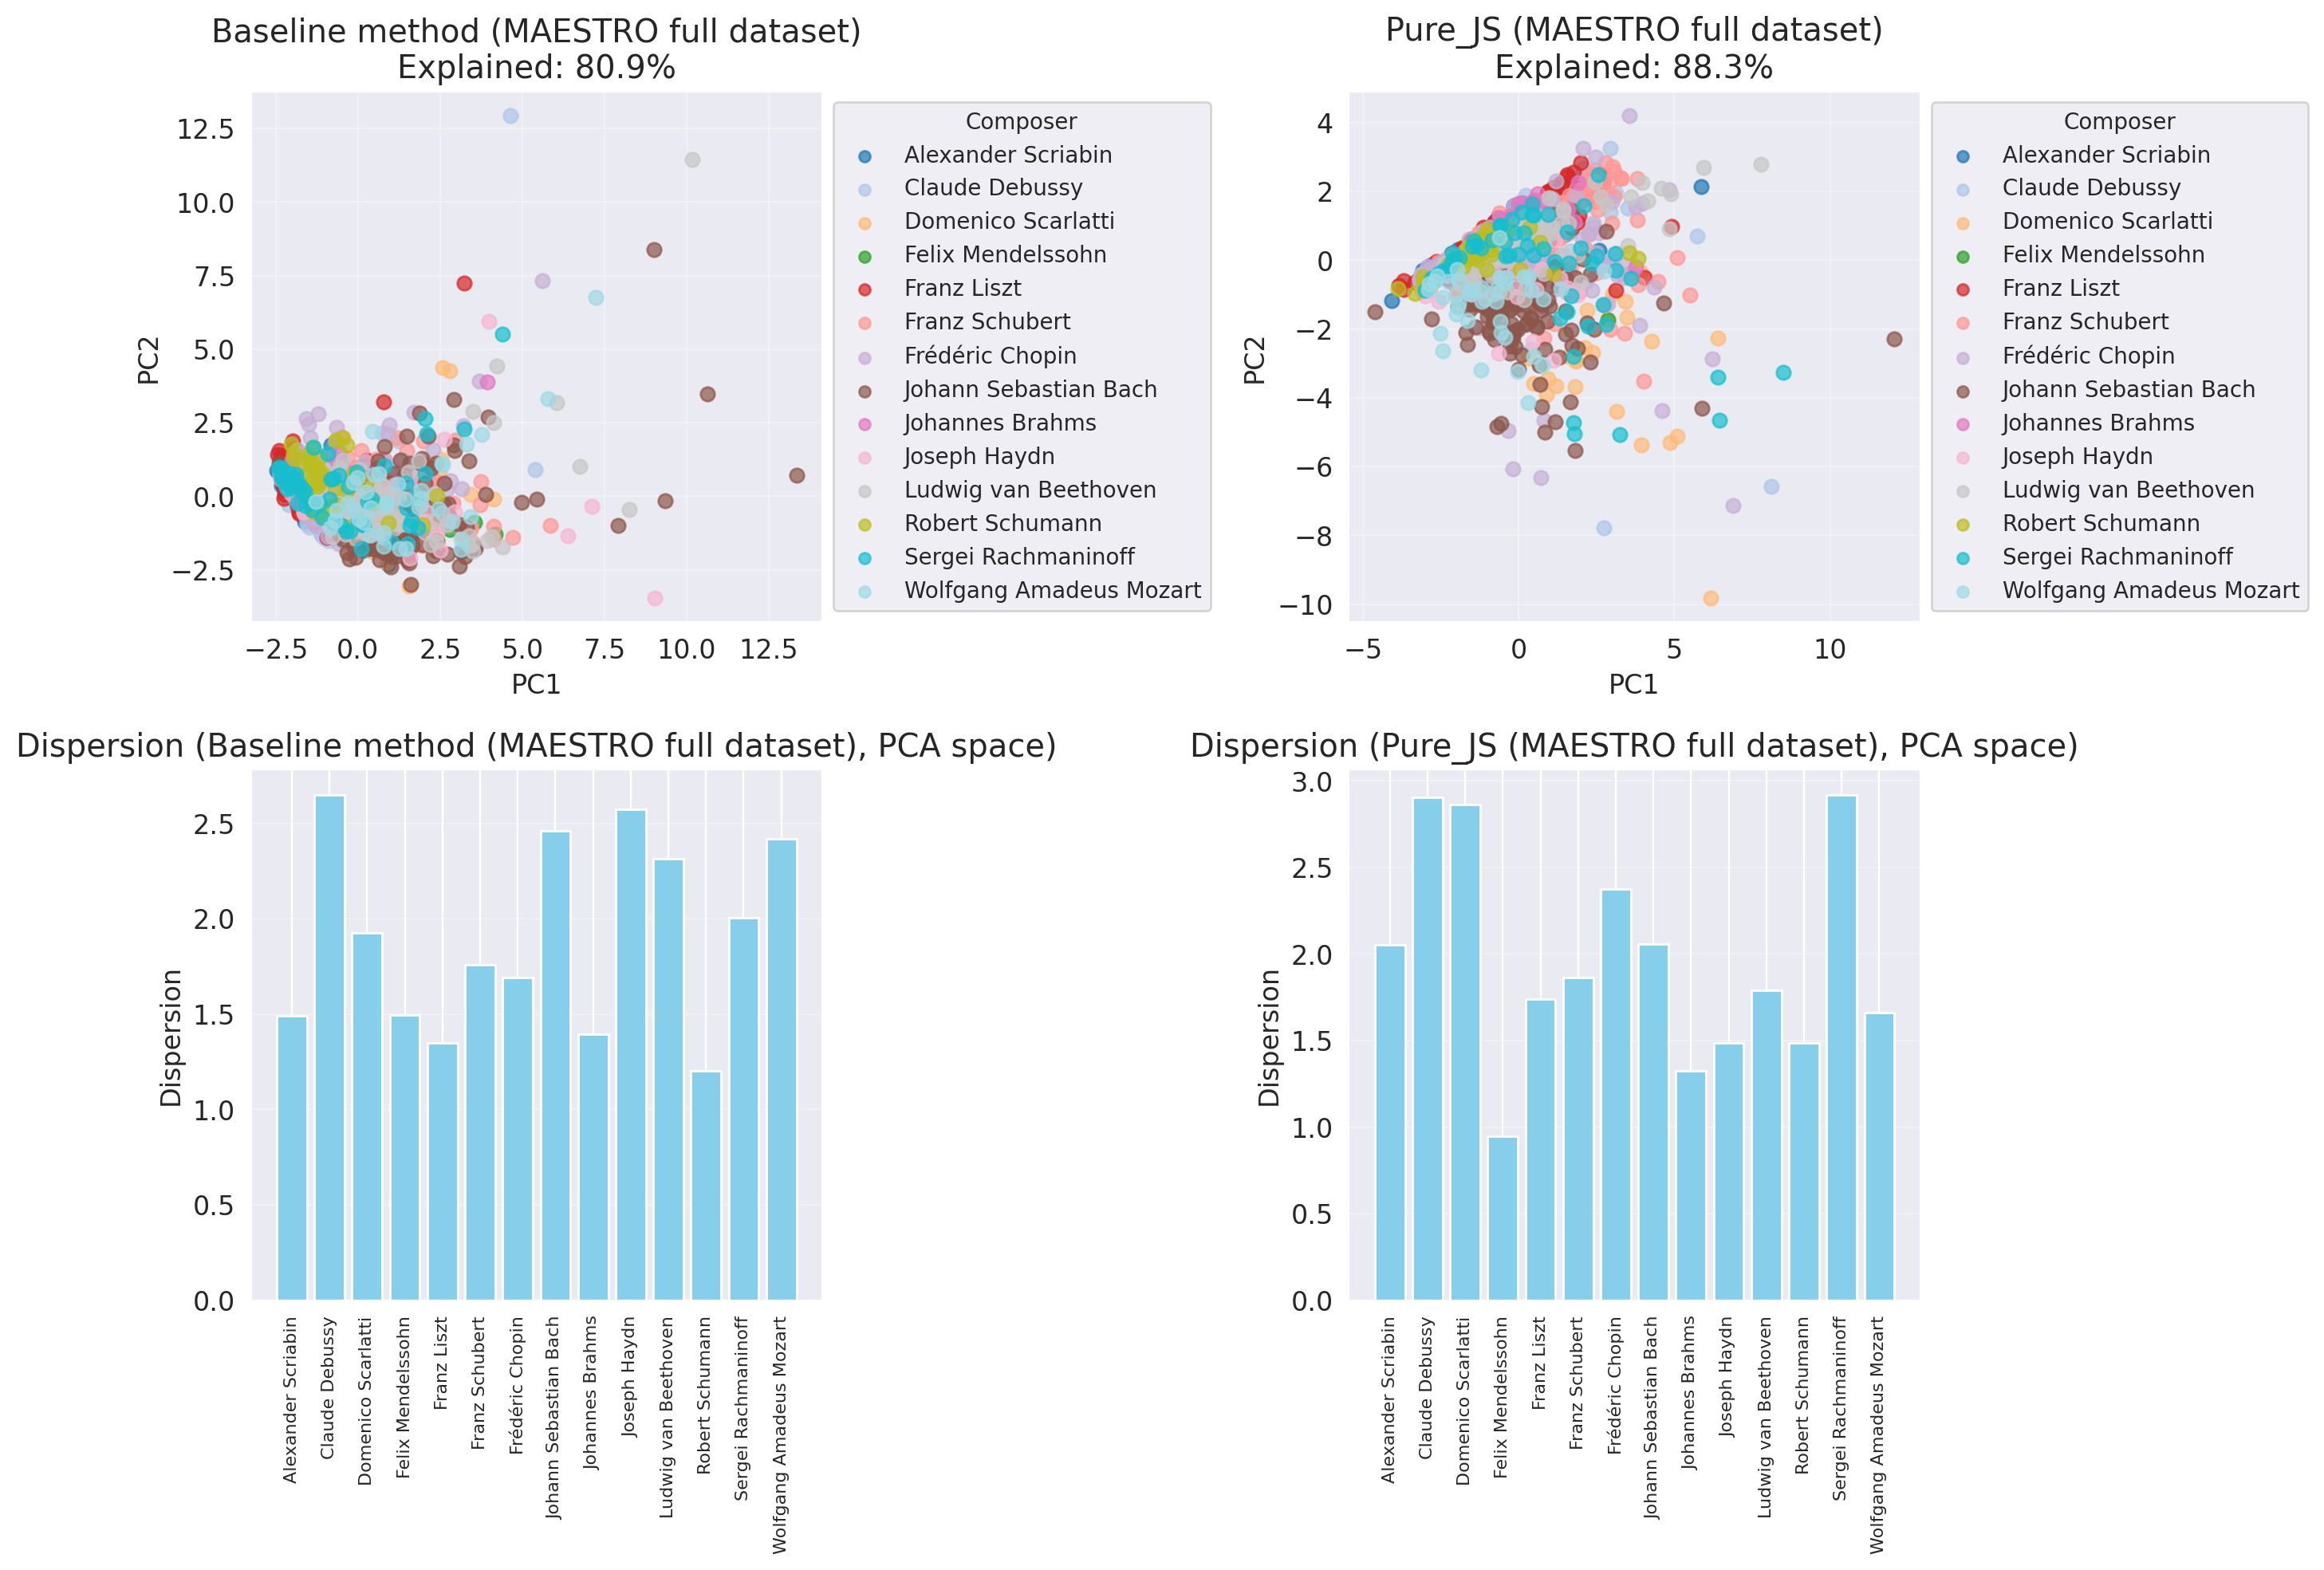

In [7]:
# Experiment on full-trimmed MAESTRO dataset
small_results_js = run_small_dataset_pipeline(
    df_small=df_filtered,
    refresh_parts=False,
    apply_sqrt=False,
    use_pure_js=True,
    js_scale=1.0,
    edge_eps=1e-6,
    min_num_parts=1,
    composer_order=None,
    plot_title_suffix=" (MAESTRO full dataset)"
)

## Results:

### MAESTRO validation split

The validation-split experiment provides a useful stress test of the method on a corpus that is much broader than the Haydn–Mozart–Beethoven quartet collection and, at the same time, substantially imbalanced across composers. Despite this imbalance, the comparison remains informative: the class sizes vary considerably, from 31 works for Chopin down to only a few works for several composers, yet the resulting geometric picture is not dominated by a single trivial artifact of sample size alone.

On the validation split, the pure JS metric improves most of the aggregate metrics reported in the experiment. The explained variance of the first two principal components increases from 0.7883 to 0.8809, the silhouette score in the full feature space improves from -0.3413 to -0.2799, and the silhouette score in the PCA plane improves from -0.4306 to -0.3709. The average distance between class centroids also increases from 1.8393 to 2.0650. At the same time, the Davies–Bouldin index worsens from 3.8925 to 4.8380. Taken together, these changes indicate that on this broader and noisier corpus the pure JS construction yields a more expressive low-dimensional representation and a somewhat clearer global separation of composer classes, although not every scalar compactness criterion improves simultaneously.

At the same time, the dispersion profile remains heterogeneous, which is natural for a stylistically broad multi-composer dataset. Some composers become more compact under the pure JS geometry, while others become more dispersed. This should not be read as a defect of the method. Rather, it reflects the fact that the metric reacts to the internal variability of the represented repertoire rather than merely compressing all classes toward a common scale. In particular, the absence of any single extreme collapse or explosion across the bar plots suggests that the geometry remains structurally stable even under severe class imbalance.

This point is important methodologically. Since the MAESTRO validation split is much more imbalanced than the original quartet corpus, yet still produces coherent and nontrivial results, it becomes harder to argue that the earlier observations were driven only by dataset imbalance. The MAESTRO experiment therefore supports a more cautious and stronger conclusion: imbalance certainly affects interpretation, but it does not by itself explain away the geometric effects observed under the pure JS metric.

### Full MAESTRO corpus

The experiment on the full MAESTRO corpus is even more demanding, since it combines a much larger sample size with a wide stylistic range and substantial class imbalance. Here again the pure JS metric does not behave as a simple clustering optimizer; instead, it changes the geometry in a more selective way.

On the full corpus, the explained variance of the first two principal components increases from 0.8087 to 0.8829, the Davies–Bouldin index improves markedly from 10.4395 to 7.9020, and the average centroid distance increases from 1.3471 to 1.6510. These changes indicate that the overall large-scale organization of the composer clouds becomes more structured under the pure JS representation. In particular, the PCA projection becomes more concentrated and visually more interpretable at the global level.

However, the silhouette scores deteriorate: in the full feature space the value changes from -0.1773 to -0.2190, and in the PCA plane from -0.2194 to -0.2964. Thus, the pure JS metric does not improve local neighborhood coherence on this highly heterogeneous corpus. This is consistent with what we observed earlier on the large custom dataset: the main contribution of the new metric is often to reshape global geometry rather than to optimize local cluster compactness.

The dispersion bars again provide an important robustness argument. Even though the class sizes differ strongly, from more than 200 works for Chopin to only a few dozen for several other composers, the results do not show a trivial monotone relationship between sample size and spread. Large classes are not automatically the most dispersed, and smaller classes are not automatically the most compact. This supports the idea that the measured structure is not merely an artifact of imbalance. Instead, the pure JS geometry appears to capture genuine differences in the internal organization of the represented composer corpora.

For this reason, the full MAESTRO experiment should be interpreted positively but cautiously. It does not show a universal gain in every numerical metric. What it does show is that the pure JS metric remains meaningful and structurally stable even on a much broader, noisier, and more imbalanced corpus than the original dataset. This is valuable external evidence that the method is not overfitted to the initial Haydn–Mozart–Beethoven setting.

### **Overall**

Taken together, the validation-split and full-corpus MAESTRO experiments support two conclusions.

First, the pure JS metric transfers nontrivially beyond the original string-quartet dataset. Even on a broader piano corpus with many composers and strong class imbalance, it still produces coherent geometric changes rather than degenerate behavior.

Second, the MAESTRO results reinforce the interpretation already suggested by the custom corpora: the pure JS metric is most useful as a tool for improving global geometric interpretability, not as a universal optimizer of all local clustering scores. On the validation split it improves all aggregate metrics simultaneously, while on the full corpus it improves explained variance, Davies–Bouldin, and centroid separation, but not silhouette. This mixed but stable pattern is entirely consistent with the overall logic of the study.

In this sense, the MAESTRO experiments function as an external robustness check. They show that the main observations obtained on the custom datasets cannot be reduced to a narrow artifact of corpus design alone. Even under strong imbalance and a much wider stylistic range, the pure JS construction continues to reveal a meaningful and interpretable geometry.